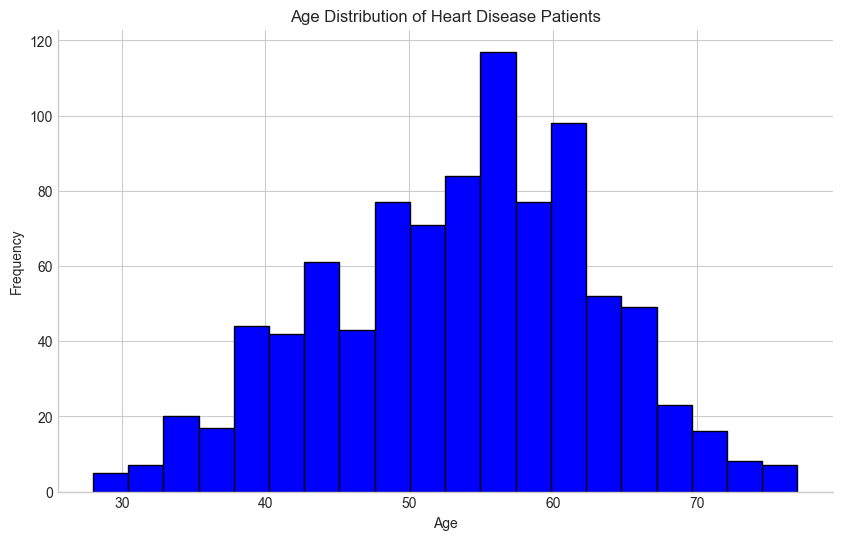

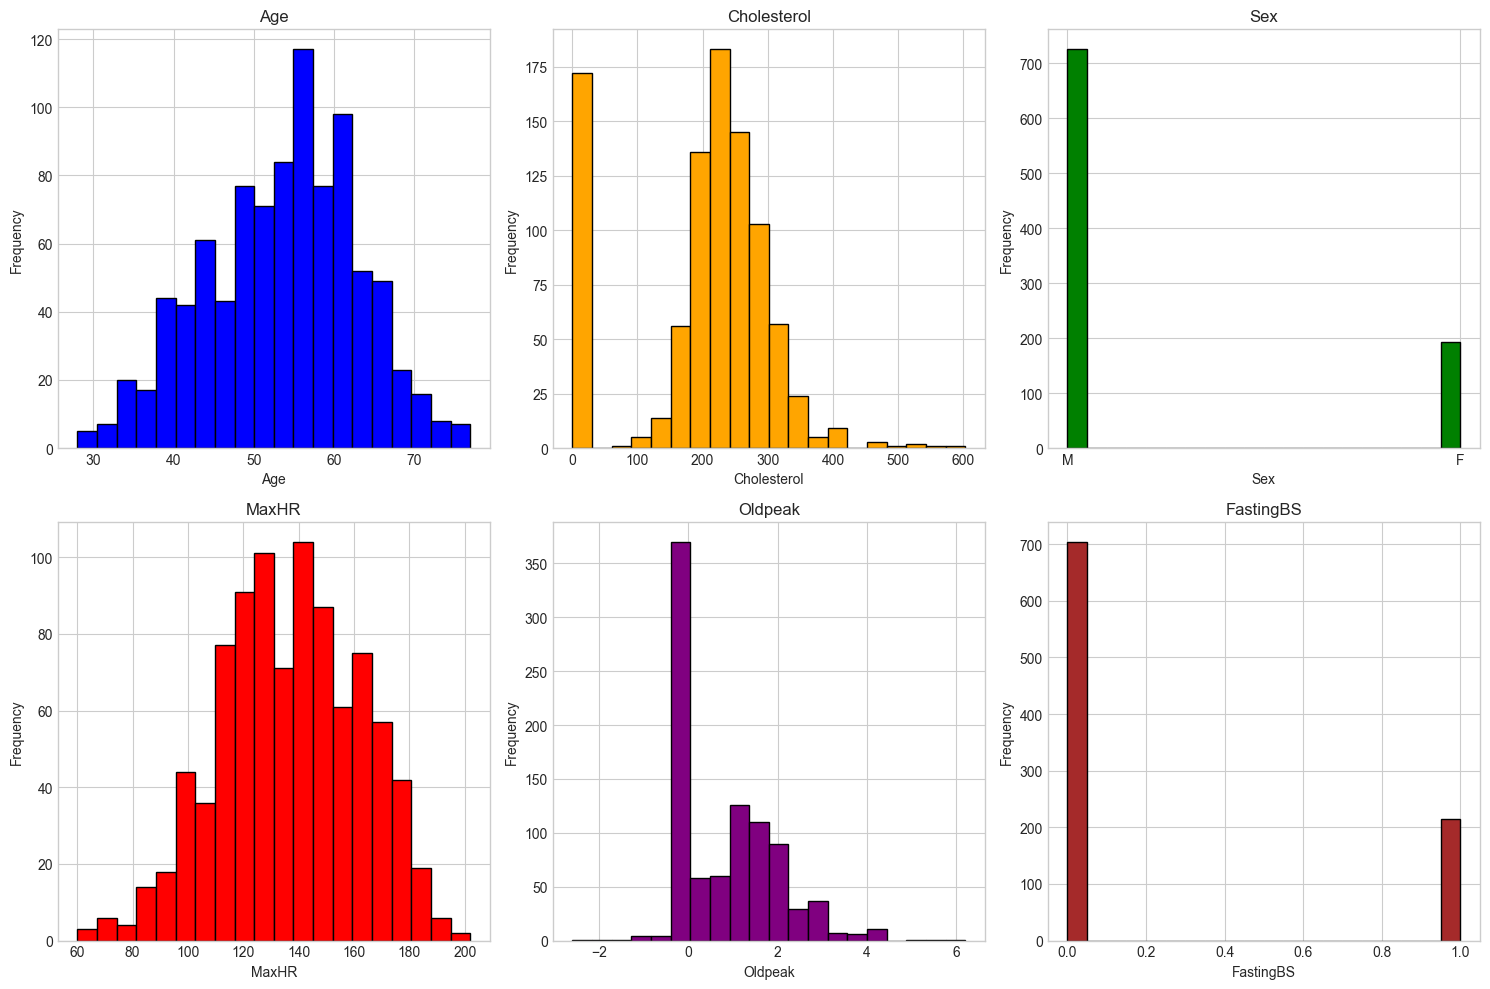

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


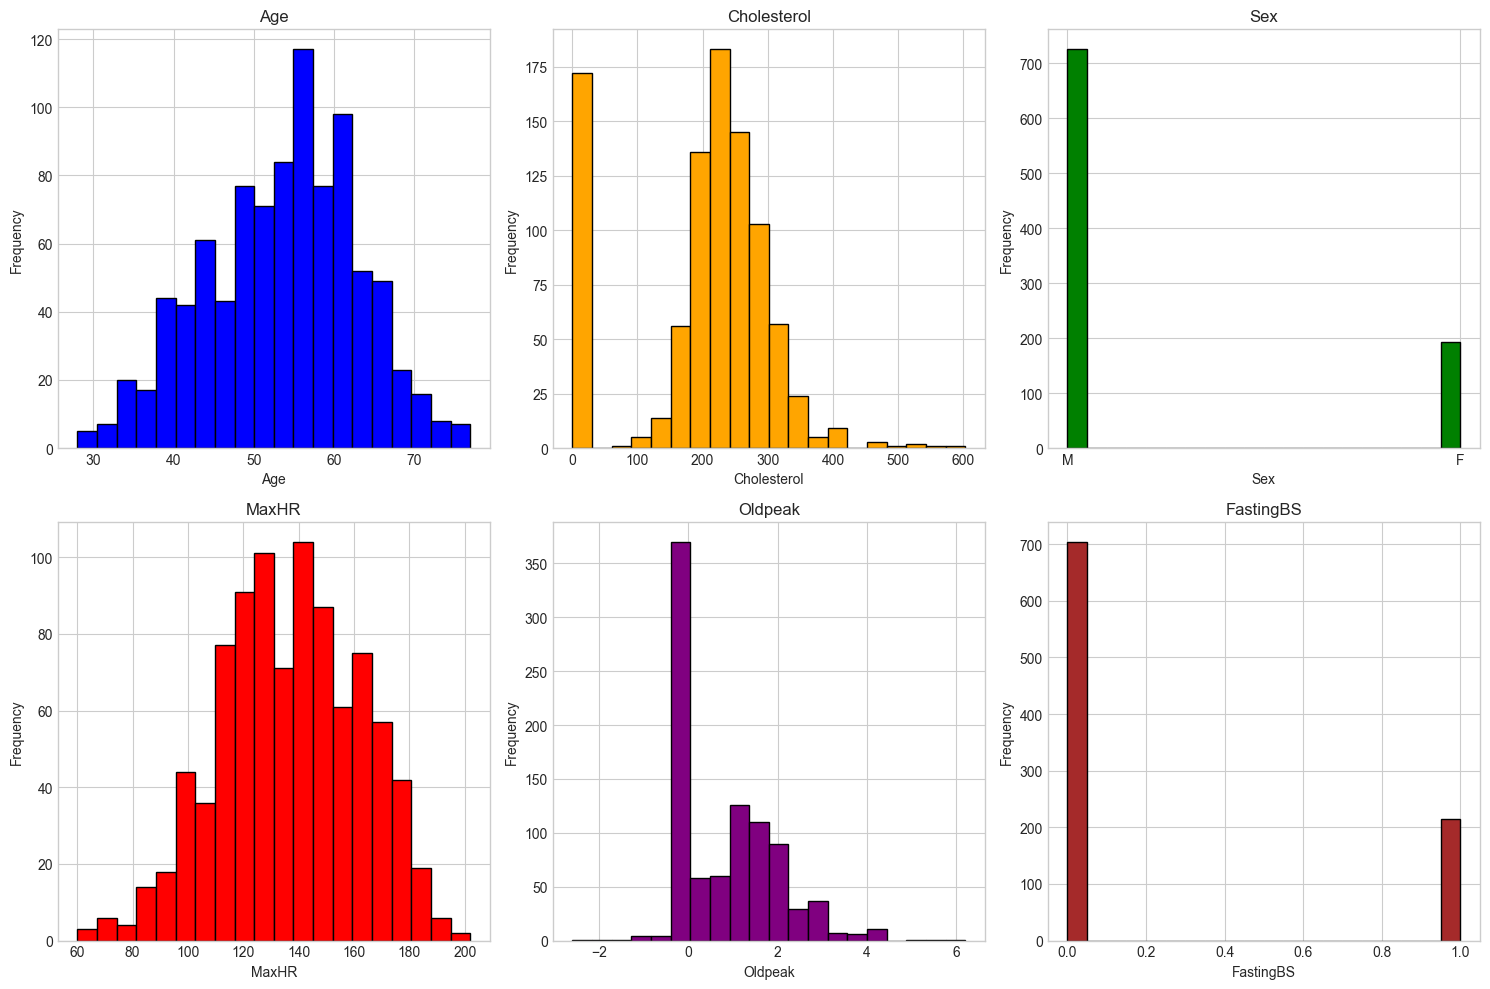

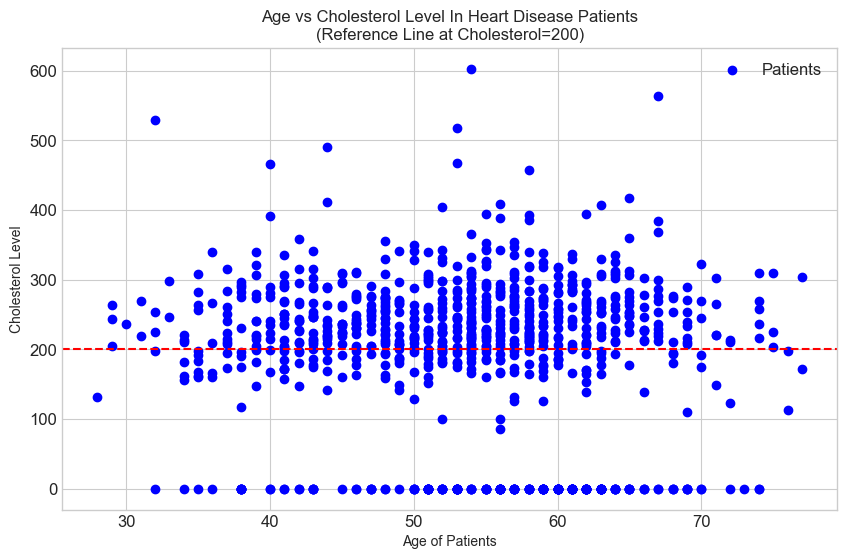

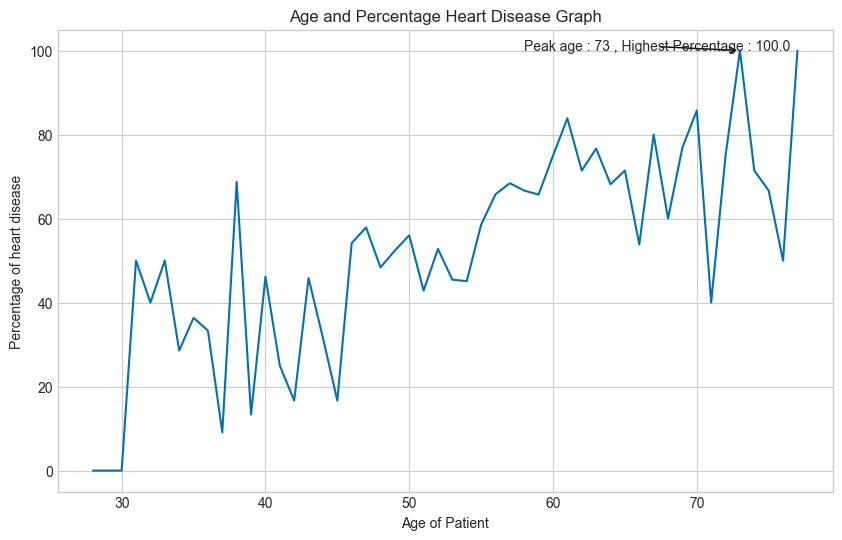

C:\Users\User\AppData\Local\Temp\ipykernel_5936\1405287950.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='HeartDisease', data=df, palette='Blues', ax=axes[0, 0])
C:\Users\User\AppData\Local\Temp\ipykernel_5936\1405287950.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='HeartDisease', data=df, palette='coolwarm', ax=axes[0, 1])
C:\Users\User\AppData\Local\Temp\ipykernel_5936\1405287950.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='HeartDisease', data=df, palette='Set2', ax=axes[1, 0])
C:\Users\User\AppData\Loca

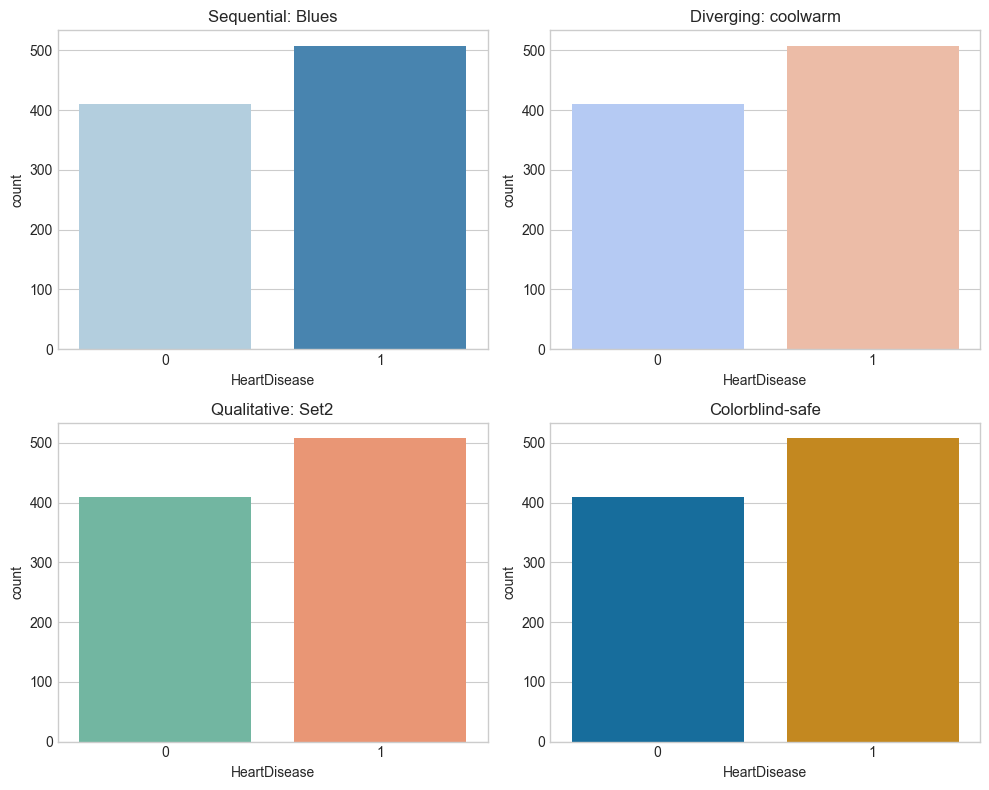

In [34]:
#Day 1 of Week 2
#Exercise 1: Create a single chart using explicit fig, ax = plt.subplots() syntax — Age histogram with title, x/y labels, no top/right borders, saved to charts/ folder
#Exercise 2: Create a 2×3 subplot grid showing 6 different columns from heart.csv — each with its own title and color — use axes.flat to apply clean styling to all in one loop
#Exercise 3: Apply plt.style.use('seaborn-v0_8-whitegrid') at top of notebook — then recreate Exercise 2 and compare the difference
#Exercise 4: Create a scatterplot of Age vs Cholesterol — add a reference line at Cholesterol=200 with label, add subtitle text below main title, customize tick sizes and legend
#Exercise 5: Calculate heart disease risk % by age — plot as a line chart — annotate the peak risk age with an arrow callout box pointing to that data point
#Exercise 6: Create 4 subplots using different colormaps — one sequential (Blues), one diverging (coolwarm), one qualitative (Set2), one colorblind-safe (colorblind) — each showing the same countplot

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/Heart.csv')

# Ex1
fig , ax = plt.subplots(figsize=(10,6))
ax.hist(df['Age'], bins=20, color='blue', edgecolor='black')
ax.set_title('Age Distribution of Heart Disease Patients')
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Ex2
fig , axis = plt.subplots(2,3,figsize=(15,10))
columns = ['Age', 'Cholesterol', 'Sex', 'MaxHR', 'Oldpeak', 'FastingBS']
colors = ['blue', 'orange', 'green', 'red' ,'purple', 'brown']
for ax ,col ,color in zip(axis.flat , columns ,colors):
    ax.hist(df[col], bins=20,color=color,edgecolor='black')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

#Ex3
print(plt.style.available)
plt.style.use('seaborn-v0_8-whitegrid')
fig , axis = plt.subplots(2,3,figsize=(15,10))
columns = ['Age', 'Cholesterol', 'Sex', 'MaxHR', 'Oldpeak', 'FastingBS']
colors = ['blue', 'orange', 'green', 'red' ,'purple', 'brown']
for ax ,col ,color in zip(axis.flat , columns ,colors):
    ax.hist(df[col], bins=20,color=color,edgecolor='black')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

#ex4

fig , ax = plt.subplots(figsize=(10,6))
ax.scatter(df['Age'], df['Cholesterol'], color='blue', label='Patients')
ax.set_xlabel('Age of Patients')
ax.set_ylabel('Cholesterol Level')
ax.set_title('Age vs Cholesterol Level In Heart Disease Patients\n(Reference Line at Cholesterol=200)')
ax.tick_params(axis='both', labelsize=12)
ax.legend(fontsize=12, framealpha=0.8)
ax.axhline(y=200 , color='red', linestyle='--', label='Cholesterol=200')
plt.show()

#Ex5

age_risk = df.groupby('Age')['HeartDisease'].mean()*100
age_risk_df = age_risk.reset_index()
age_risk_df.columns = ['Age', '% Heart Disease']
age_risk_df = age_risk_df.sort_values(by='Age')
peak = age_risk_df.loc[age_risk_df['% Heart Disease'].idxmax()]

fig , ax = plt.subplots(figsize=(10,6))
ax.plot(age_risk_df['Age'], age_risk_df['% Heart Disease'])
ax.set_title('Age and Percentage Heart Disease Graph')
ax.set_xlabel('Age of Patient')
ax.set_ylabel('Percentage of heart disease')
ax.annotate(
    f"Peak age : {int(peak['Age'])} , Highest Percentage : {peak['% Heart Disease']:.1f}" ,
    xy= (peak['Age'], peak['% Heart Disease']),
    xytext= (peak['Age']-15 , peak['% Heart Disease']),
    arrowprops= dict(arrowstyle='->')
)

plt.show()

#Ex 6

fig, axes = plt.subplots(2, 2, figsize=(10, 8))


sns.countplot(x='HeartDisease', data=df, palette='Blues', ax=axes[0, 0])
axes[0, 0].set_title('Sequential: Blues')


sns.countplot(x='HeartDisease', data=df, palette='coolwarm', ax=axes[0, 1])
axes[0, 1].set_title('Diverging: coolwarm')


sns.countplot(x='HeartDisease', data=df, palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('Qualitative: Set2')


sns.countplot(x='HeartDisease', data=df, palette='colorblind', ax=axes[1, 1])
axes[1, 1].set_title('Colorblind-safe')


plt.tight_layout()

plt.show()

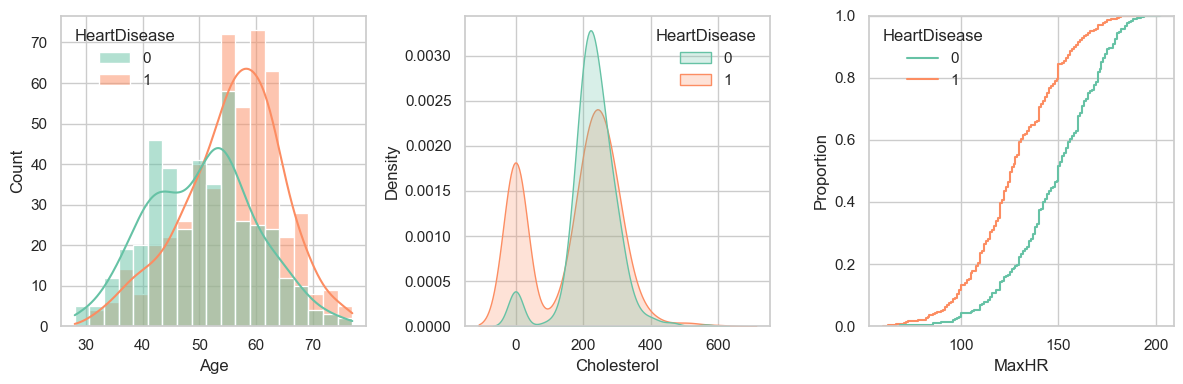

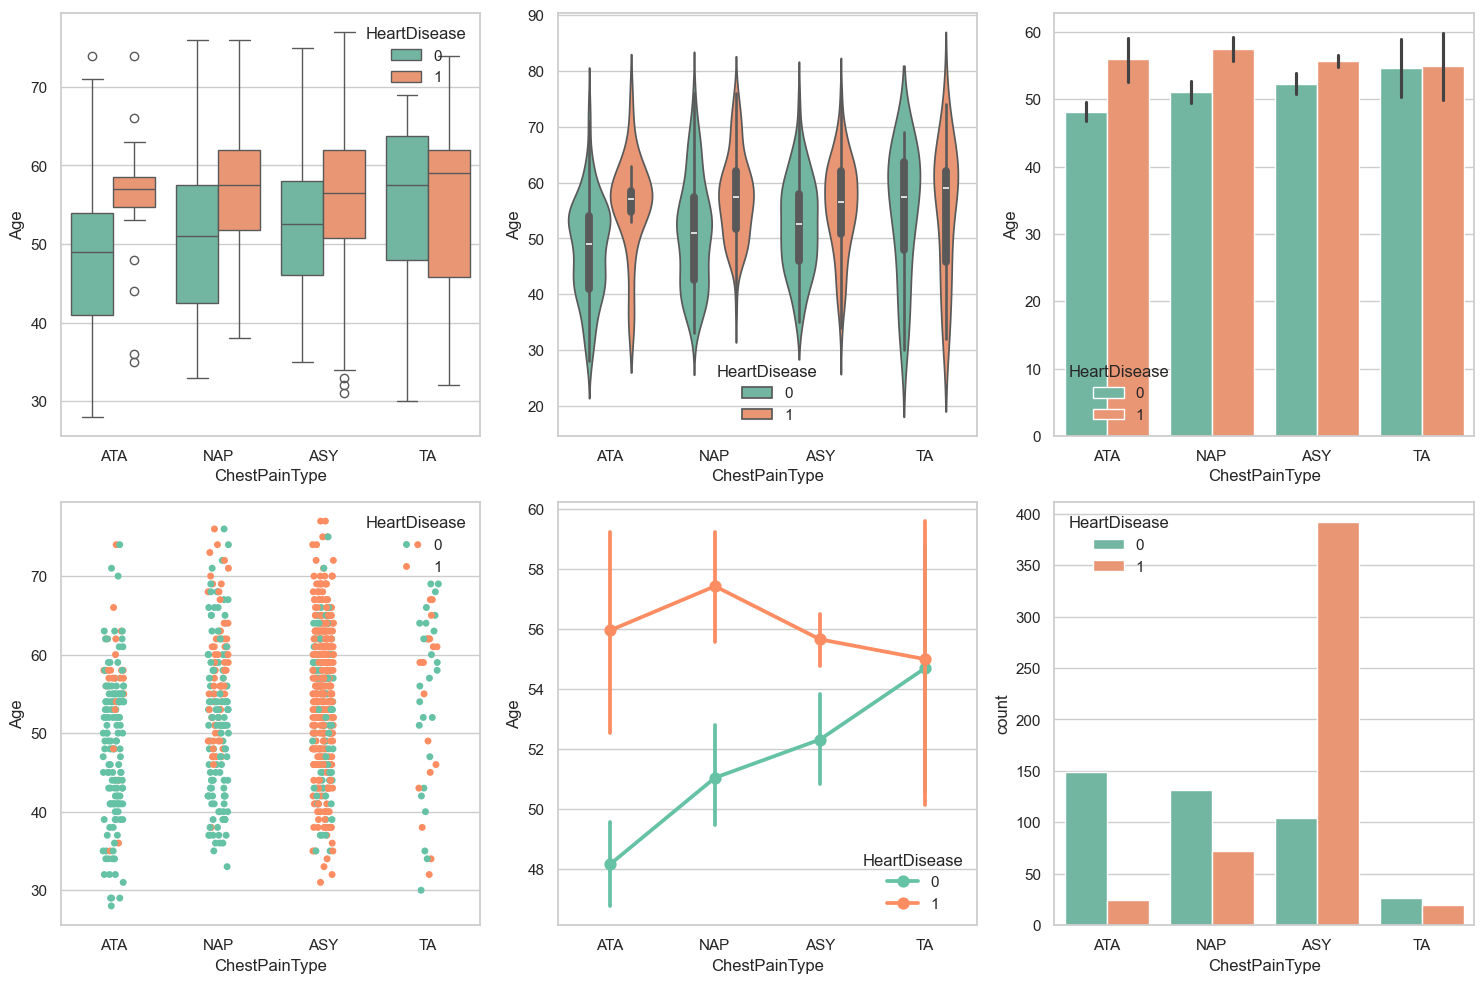

In [45]:
#Day 2 of week 3
#Exercise 1: Set sns.set_theme(style='whitegrid', palette='Set2') at top — confirm it affects all subsequent charts automatically
#Exercise 2: Create a 1×3 figure — histplot of Age with kde=True, kdeplot of Cholesterol with fill=True, ecdfplot of MaxHR — all colored by HeartDisease
#Exercise 3: Create a 2×3 figure of all 6 categorical plots — boxplot, violinplot, stripplot, barplot, countplot, pointplot — X axis = ChestPainType, Y axis = Age, hue = HeartDisease
#Exercise 4: Create a 1×3 relational figure — scatterplot of Age vs MaxHR (hue=HeartDisease, size=Cholesterol), lineplot of same variables, regplot without hue — note what each adds
#Exercise 5: Create a pairplot of Age, Cholesterol, MaxHR, Oldpeak, HeartDisease — hue=HeartDisease, diag_kind='kde', alpha=0.5 — write one sentence about the most interesting finding
#Exercise 6: Create a heatmap — lower triangle only using mask — annotated, fmt='.2f', coolwarm, center=0 — then create a horizontal bar chart of all feature correlations with HeartDisease sorted by absolute value
#Exercise 7: Save all charts to charts/ folder at dpi=300 using plt.savefig()

import matplotlib.pyplot as plt
import seaborn as sns

#Ex1
sns.set_theme(style='whitegrid', palette='Set2')

#Ex2
fig , axis = plt.subplots(1,3 ,figsize=(12,4))
sns.histplot(x='Age', kde=True , hue='HeartDisease', data=df, ax=axis[0])
sns.kdeplot(x='Cholesterol', fill=True, hue='HeartDisease', data=df, ax=axis[1])
sns.ecdfplot(x='MaxHR', hue='HeartDisease', data=df, ax=axis[2])
plt.tight_layout()
plt.show()

#Ex3
fig , axis = plt.subplots(2,3,figsize=(15,10))
sns.boxplot(x='ChestPainType', y='Age', hue='HeartDisease', data=df, ax=axis[0,0])
sns.violinplot(x='ChestPainType', y='Age', hue='HeartDisease', data=df , ax=axis[0,1])
sns.barplot(x='ChestPainType', y='Age',hue='HeartDisease',data=df , ax=axis[0,2])
sns.stripplot(x='ChestPainType', y='Age', hue='HeartDisease', data=df, ax=axis[1,0])
sns.pointplot(x='ChestPainType', y='Age', hue='HeartDisease', data=df, ax=axis[1,1])
sns.countplot(x='ChestPainType',  hue='HeartDisease', data=df , ax=axis[1,2])
plt.tight_layout()
plt.show()